<a href="https://colab.research.google.com/github/italo-404/fraud-detection/blob/main/deteccao_fraudes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving creditcard.csv to creditcard.csv


Total de transações: 284,807
Colunas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.5146

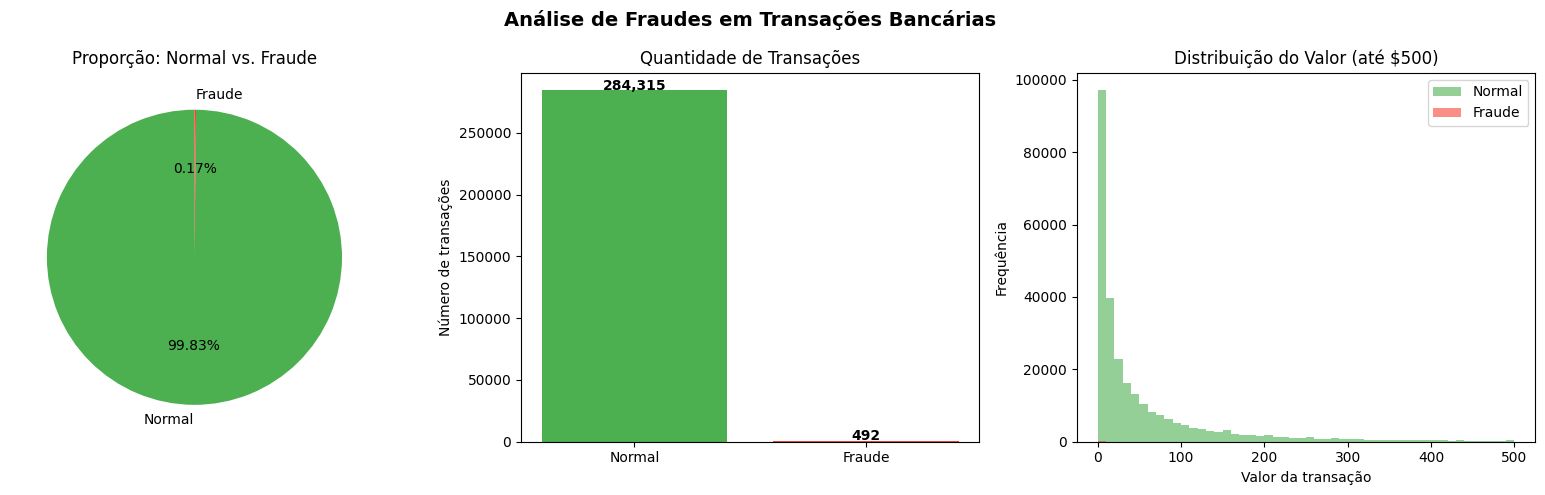


Treino: 227,845 registros | Teste: 56,962 registros

Relatório de Classificação:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.89      0.78      0.83        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



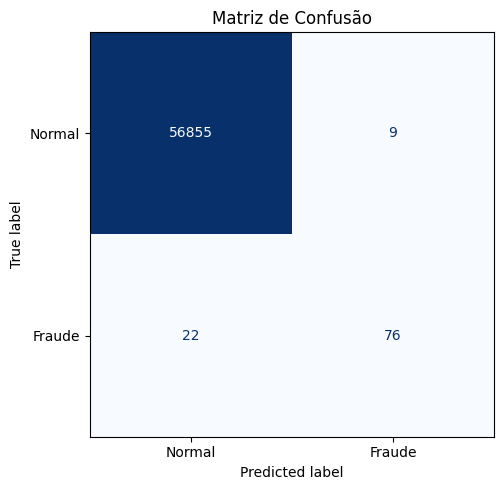


Acurácia: 99.95%
Fraudes detectadas: 76 de 98 (77.6%)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


# --- 1. Carregamento dos dados ---

df = pd.read_csv("creditcard.csv")

print(f"Total de transações: {len(df):,}")
print(f"Colunas: {list(df.columns)}\n")
print(df.head())


# --- 2. Análise exploratória (EDA) ---

contagem = df["Class"].value_counts()
percentual_fraude = (contagem[1] / len(df)) * 100

print(f"\nTransações normais: {contagem[0]:,}")
print(f"Transações fraudulentas: {contagem[1]:,} ({percentual_fraude:.4f}%)")
print("\nValores nulos:\n", df.isnull().sum())
print("\nEstatísticas de 'Amount':\n", df["Amount"].describe().round(2))
print("\nValor médio por classe:\n", df.groupby("Class")["Amount"].mean())


# --- 3. Visualizações ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Análise de Fraudes em Transações Bancárias", fontsize=14, fontweight="bold")

cores = ["#4CAF50", "#F44336"]
valores = [contagem[0], contagem[1]]

axes[0].pie(valores, labels=["Normal", "Fraude"], colors=cores, autopct="%1.2f%%", startangle=90)
axes[0].set_title("Proporção: Normal vs. Fraude")

axes[1].bar(["Normal", "Fraude"], valores, color=cores)
axes[1].set_title("Quantidade de Transações")
axes[1].set_ylabel("Número de transações")
for i, v in enumerate(valores):
    axes[1].text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")

normais = df[df["Class"] == 0]["Amount"]
fraudes = df[df["Class"] == 1]["Amount"]
axes[2].hist(normais, bins=50, color=cores[0], alpha=0.6, label="Normal", range=(0, 500))
axes[2].hist(fraudes, bins=50, color=cores[1], alpha=0.6, label="Fraude", range=(0, 500))
axes[2].set_title("Distribuição do Valor (até $500)")
axes[2].set_xlabel("Valor da transação")
axes[2].set_ylabel("Frequência")
axes[2].legend()

plt.tight_layout()
plt.show()


# --- 4. Preparação para o modelo ---

X = df.drop(columns=["Class"])
y = df["Class"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTreino: {len(X_treino):,} registros | Teste: {len(X_teste):,} registros")


# --- 5. Treinamento do modelo ---

modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo.fit(X_treino, y_treino)


# --- 6. Avaliação ---

y_pred = modelo.predict(X_teste)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, y_pred, target_names=["Normal", "Fraude"]))

cm = confusion_matrix(y_teste, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraude"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de Confusão")
plt.tight_layout()
plt.show()

vn, fp, fn, vp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
acuracia = (vn + vp) / (vn + fp + fn + vp) * 100
print(f"\nAcurácia: {acuracia:.2f}%")
print(f"Fraudes detectadas: {vp} de {vp + fn} ({vp / (vp + fn) * 100:.1f}%)")
